# The attention value of a win in mixed martial arts

Figures and abstract for the SSAC 2027 submission.
Pre-registered: **OSF 10.17605/OSF.IO/DXUPH**. Analysis lives in `prep/z_analysis.py`;
this notebook only reads its outputs and draws.

Run top to bottom. Figures are written to `figures/` at 300 dpi.


In [1]:
import csv, math, sys
from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA, FIGS = ROOT / "data", ROOT / "figures"
FIGS.mkdir(exist_ok=True)

# Validated categorical pair (dataviz skill: ALL CHECKS PASS, light surface).
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"

mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300, "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 10,
    "axes.edgecolor": "#d8d7d2", "axes.linewidth": 0.8, "axes.grid": False,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.labelcolor": INK, "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "legend.frameon": False,
})
print("ready")

ready


In [2]:
# --- data -------------------------------------------------------------------
bouts = {int(r["bout_id"]): r for r in csv.DictReader(open(DATA / "bout_D_S.csv"))}
strikes = {int(r["bout_id"]): r for r in csv.DictReader(open(DATA / "b_sig_strikes.csv"))
           if r["winner_share"]}

p, D = [], []
for bid, b in bouts.items():
    if b["in_sample_b"] == "True" and bid in strikes:
        p.append(float(strikes[bid]["winner_share"]) - 0.5)
        D.append(float(b["D"]))
p, D = np.array(p), np.array(D)
X = np.column_stack([np.ones(len(p)), p])
alpha, beta = np.linalg.lstsq(X, D, rcond=None)[0]
print(f"n = {len(p)}   alpha = {alpha:+.3f}   beta = {beta:+.3f}")

n = 309   alpha = +0.283   beta = +0.789


## Figure 1 — the attention gap at equal output

**The winner gets the spotlight even when output was even.** Each dot is one split
decision. The horizontal axis shows how the strikes split between the fighters: 50/50 in
the centre, 60/40 in the winner's favour to the right, and the loser landing more to the
left. The vertical axis shows how much more attention the winner gained than the loser.
If attention simply followed performance, the line would pass through zero at 50/50.
Instead it sits 0.28 log points above zero, a 33% gap, when both fighters landed equally.
The line barely rises as the winner's edge grows. The gap holds whether or not main events
are included, with betting odds added as a control, with each year dropped in turn, and
over days 31–90.

*(The percent scale is linear in log points, so equal distances are equal ratios; 11 of
309 bouts fall outside the axis and are drawn at its edge.)*

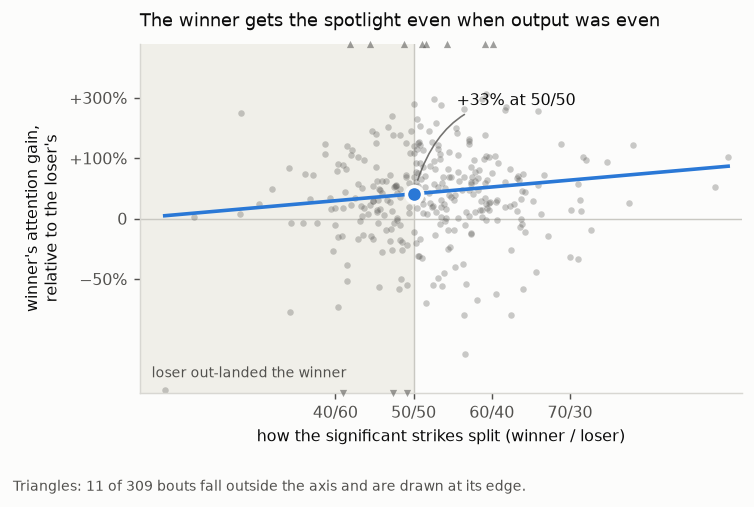

In [3]:
fig, ax = plt.subplots(figsize=(5.8, 3.6))

CLIP = 2.0                      # log points; dots beyond this are drawn at the edge
below, above = D < -CLIP, D > CLIP
inside = ~(below | above)

# the half where the LOSER out-landed the winner
ax.axvspan(-0.35, 0, color="#f0efe9", zorder=0)
ax.text(-0.335, -CLIP * 0.93, "loser out-landed the winner", fontsize=7.5,
        color=INK2, ha="left", va="bottom")

ax.axhline(0, color="#c9c8c2", lw=0.8, zorder=1)
ax.axvline(0, color="#c9c8c2", lw=0.8, zorder=1)
ax.scatter(p[inside], D[inside], s=13, color=INK2, alpha=0.30, linewidths=0, zorder=2)
# outliers pinned to the edge, so they are visible without squashing the cloud
ax.scatter(p[above], np.full(above.sum(), CLIP), s=16, marker="^", color=INK2,
           alpha=0.55, linewidths=0, zorder=3, clip_on=False)
ax.scatter(p[below], np.full(below.sum(), -CLIP), s=16, marker="v", color=INK2,
           alpha=0.55, linewidths=0, zorder=3, clip_on=False)

xs = np.linspace(p.min(), p.max(), 100)
ax.plot(xs, alpha + beta * xs, color=BLUE, lw=2, zorder=4)
ax.plot([0], [alpha], marker="o", ms=9, color=BLUE, mec=SURFACE, mew=2, zorder=5)
ax.annotate(f"+{100*(math.exp(alpha)-1):.0f}% at 50/50", xy=(0, alpha),
            xytext=(0.055, 1.35), color=INK, fontsize=9, ha="left", va="center",
            arrowprops=dict(arrowstyle="-", color=INK2, lw=0.9, alpha=0.8,
                            connectionstyle="angle3,angleA=0,angleB=75",
                            shrinkA=2, shrinkB=8))

# y in percent: round percentages, placed at their true log positions, so the
# geometry stays honest (equal distances are equal ratios).
ypct = [-50, 0, 100, 300]
ax.set_yticks([math.log1p(v / 100) for v in ypct])
ax.set_yticklabels([("0" if v == 0 else f"{v:+d}%".replace("-", "−"))
                    for v in ypct])
ax.set_ylim(-CLIP, CLIP)

xticks = [-0.10, 0.0, 0.10, 0.20]
ax.set_xticks(xticks)
ax.set_xticklabels(["40/60", "50/50", "60/40", "70/30"])
ax.set_xlim(-0.35, 0.42)

ax.set_xlabel("how the significant strikes split (winner / loser)")
ax.set_ylabel("winner's attention gain,\nrelative to the loser's")
ax.set_title("The winner gets the spotlight even when output was even",
             loc="left", color=INK, pad=10)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.text(0.01, -0.06, f"Triangles: {int(above.sum() + below.sum())} of {len(D)} bouts fall "
         f"outside the axis and are drawn at its edge.", fontsize=7.5, color=INK2)
fig.tight_layout()
fig.savefig(FIGS / "fig1_label_effect.png", bbox_inches="tight")
plt.show()

## Figure 2 — what moves attention, and what does not

**Labels move attention; the measurable performance edge does not.** Blue are the
pre-registered tests. Winning at equal output adds +33% (95% CI 18–49%). Fight of the
Night adds +26% (16–38%). A 60/40 strike edge adds +8%, with an interval spanning zero,
which is inconclusive: the study can only detect large performance effects. Orange are
the placebo and a descriptive comparison. The placebo runs the same test on two windows
before the fight, where the effect should be zero. It returns +6% (not significant); net
of it, the win is worth 25%. Losing the night's best fight still yields 15% less attention
than winning an ordinary one. Intervals come from 10,000 bootstrap resamples of bouts,
with a Holm correction across the three tests.

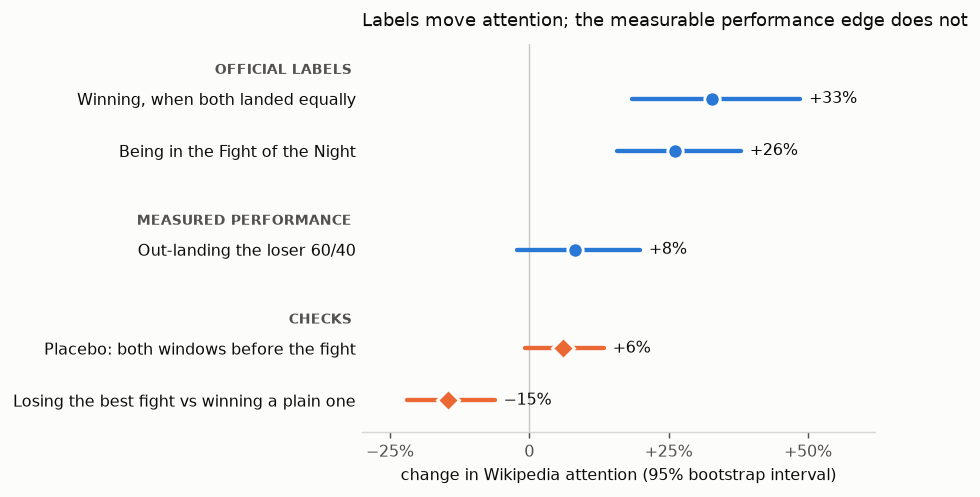

In [4]:
def pct(x):
    return 100 * (math.exp(x) - 1)

groups = [
    ("Official labels", [
        ("Winning, when both landed equally", 0.2830, 0.1687, 0.3960, BLUE, "o"),
        ("Being in the Fight of the Night",   0.2322, 0.1462, 0.3218, BLUE, "o"),
    ]),
    ("Measured performance", [
        ("Out-landing the loser 60/40",       0.0789, -0.0224, 0.1811, BLUE, "o"),
    ]),
    ("Checks", [
        ("Placebo: both windows before the fight", 0.0581, -0.0082, 0.1254, ORANGE, "D"),
        ("Losing the best fight vs winning a plain one", -0.1572, -0.2486, -0.0642,
         ORANGE, "D"),
    ]),
]

rows, labels, heads = [], [], []
y = 0.0
for gname, items in groups:
    heads.append((y, gname))
    y -= 0.55
    for it in items:
        rows.append((y, *it)); labels.append((y, it[0]))
        y -= 1.0
    y -= 0.35

fig, ax = plt.subplots(figsize=(6.9, 3.9))
ax.axvline(0, color="#c9c8c2", lw=0.8, zorder=1)
for yy, label, est, lo, hi, colour, marker in rows:
    ax.plot([pct(lo), pct(hi)], [yy, yy], color=colour, lw=2.4,
            solid_capstyle="round", zorder=3)
    ax.plot([pct(est)], [yy], marker=marker, ms=8.5, color=colour,
            mec=SURFACE, mew=1.6, zorder=4)
    ax.text(pct(hi) + 1.6, yy, f"{pct(est):+.0f}%".replace("-", "−"),
            va="center", ha="left", color=INK, fontsize=9)

ax.set_yticks([yy for yy, _ in labels])
ax.set_yticklabels([lab for _, lab in labels], color=INK)
for yy, gname in heads:
    ax.text(-0.02, yy, gname.upper(), transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=8, color=INK2, fontweight="bold")

ax.set_xlabel("change in Wikipedia attention (95% bootstrap interval)")
ax.set_title("Labels move attention; the measurable performance edge does not",
             loc="left", color=INK, pad=10, fontsize=10)
ax.set_xlim(-30, 62)
ax.set_xticks([-25, 0, 25, 50])
ax.set_xticklabels(["−25%", "0", "+25%", "+50%"])
ax.set_ylim(min(yy for yy, *_ in rows) - 0.6, 0.5)
for sp in ("top", "right", "left"):
    ax.spines[sp].set_visible(False)
ax.tick_params(axis="y", length=0)
fig.tight_layout()
fig.savefig(FIGS / "fig2_estimates.png", bbox_inches="tight")
plt.show()

## Abstract (draft)

**The attention value of a win in mixed martial arts**

**Introduction.** Attention concentrates on winners, but why is unclear. Rosen's superstar
account says attention tracks talent, amplified; Adler's says it can attach to an
arbitrary early advantage and compound. Separating them is hard, because winners usually
did perform better. Split decisions break the tie: the judges disagreed, so performance
was near-equal, while the label is close to arbitrary.

**Methods.** 562 UFC split decisions, 2015-08-30 to 2026-08-20; 309 where both fighters
held an English Wikipedia article at least 60 days old and fight statistics exist. For
each fighter, attention is the change in log mean daily Wikipedia pageviews from days
−60..−8 before the fight to +2..+30 after, excluding fight week. D is the winner's change minus the loser's; p the winner's share of significant
strikes, minus 0.5. Fitting D = α + β·p, α is the gap when output
was even and β the return to out-striking. A third asks whether Fight of the Night bouts draw
more attention (1,508 decision bouts, 147 awarded). Pre-registered (OSF
10.17605/OSF.IO/DXUPH) before any post-fight data existed; intervals bootstrap over
bouts, errors cluster on both fighters, Holm across the three tests.

**Results.** The win label is worth **+0.28 log points, a 33% attention gap**
(95% CI 0.17–0.40, p < 0.001) between two fighters who landed equally. The return to
out-striking is **indistinguishable from zero** (β = 0.79, CI −0.22–1.81); the design
detects slopes above roughly 1.1, so this is inconclusive rather than null. α is unchanged when the
control-time share enters the model (+0.284; control share itself −0.09, p = 0.53), so
control time does not account for it. Fight of the Night is worth **+0.23 log points,
26%** (CI 0.15–0.32, p < 0.001). Two pre-specified
cautions: a placebo on two pre-fight windows returns +0.06 (CI −0.01–0.13), positive
though indistinguishable from zero; net of it α is **+0.22, a 25% gap**. And losing an entertaining fight is **not** as good as winning a
dull one: FOTN losers gain 15% less than ordinary winners
(p < 0.001). α is stable across the pre-specified checks — 0.25–0.32 dropping each year,
0.29 excluding main events, 0.30 with an odds control — and **+0.30 on days +31..+90**: the gap does not decay.

**Conclusion.** In fights the judges could not separate, the official result alone
moves public attention about as much as being in the night's best fight — the two are
not distinguishable here (α − γ = +0.05, CI −0.10 to +0.20) —  while the
performance edge we can measure moves it undetectably. That is consistent with Adler's
account for close fights, though Rosen cannot be rejected: the upper bound on β would
imply a performance return exceeding the label effect. Three limits bound the claim. α is an
**upper bound** on the pure label effect: performance the strike measure cannot see loads
onto the intercept. γ is not causally identified — bonus bouts differ from others in ways
the controls only partly capture. And p is a fight-total
striking proxy, not round-by-round judging, so β bounds what strikes can explain rather
than what performance can.

In [5]:
# Word count of the abstract markdown cell above (SSAC limit: 500).
import nbformat, re
nb = nbformat.read(ROOT / "notebooks" / "abstract.ipynb", as_version=4)
cell = next(c.source for c in nb.cells
            if c.cell_type == "markdown" and c.source.lstrip().startswith("## Abstract"))
body = cell.split("**The attention value", 1)[1]
body = re.sub(r"[*_`#]", " ", body)
words = [w for w in body.split() if any(ch.isalnum() for ch in w)]
print(f"{len(words)} words (limit 500)")

500 words (limit 500)


/Users/baptisteperrier/code/baptperr/SSAC27/.venv/lib/python3.12/site-packages/nbformat/validator.py:434: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  _validate(nbdict, ref, version, version_minor, relax_add_props)
